# Data Cleaning, Preprocessing & EDA Project

In [123]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = sns.load_dataset('titanic') 
df


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


## Part 1

In [124]:
# Explore columns data types and report the number of missing values before and after conversion.Load CSV → 
# Check dtypes → Count missing values → Report before/after counts

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [125]:
df.dtypes

survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object

In [126]:
print("Missing values of data before ")
df.isnull().sum()

Missing values of data before 


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [127]:
# Check for exact duplicate rows. Then create a subset of columns ['sex', 'age', 'pclass', 'fare'] and check for duplicates again. 
# If duplicates exist, display them. Should you remove them or fill? Why or why not?Check exact duplicates 
# Check subset duplicates → Display if found → Decide remove/fill with justification

df.duplicated().sum()

np.int64(107)

In [128]:
duplicates = df[df.duplicated(subset=['sex','age','pclass','fare'])]
duplicates

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
42,0,3,male,NaN,0,0,7.8958,C,Third,man,True,NaN,Cherbourg,no,True
47,1,3,female,NaN,0,0,7.7500,Q,Third,woman,False,NaN,Queenstown,yes,True
76,0,3,male,NaN,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
77,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
87,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
877,0,3,male,19.0,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
878,0,3,male,NaN,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
881,0,3,male,33.0,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
884,0,3,male,25.0,0,0,7.0500,S,Third,man,True,NaN,Southampton,no,True


In [129]:
print("Missing values of subset=['sex','age','pclass','fare']")
duplicates.duplicated().sum()

Missing values of subset=['sex','age','pclass','fare']


np.int64(58)

In [130]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [131]:
print("duplicates are still exist in subset after remove from atual data\nso we can fix it by removing")
duplicates.duplicated().sum()

duplicates are still exist in subset after remove from atual data
so we can fix it by removing


np.int64(58)

In [132]:
duplicates.drop_duplicates(inplace=True)
duplicates.duplicated().sum()

np.int64(0)

## Part 2

In [140]:
# Calculate the median age for each combination of pclass and sex. Fill missing ages using these medians. 
# Compare original vs imputed age distribution using a histogram.Groupby (pclass, sex)
# Calculate median age → Fill NaN → Plot histogram (original vs imputed)

print("Median age by class and sex:\n", df.groupby(['pclass', 'sex'])['age'].median().round(1))

Median age by class and sex:
 pclass  sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.5
3       female    22.0
        male      25.0
Name: age, dtype: float64


In [142]:
df['age_imputed'] = df.groupby(['pclass', 'sex'])['age'].transform(lambda x: x.fillna(x.median()))
print(df['age_imputed'])

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
885    39.0
887    19.0
888    22.0
889    26.0
890    32.0
Name: age_imputed, Length: 784, dtype: float64


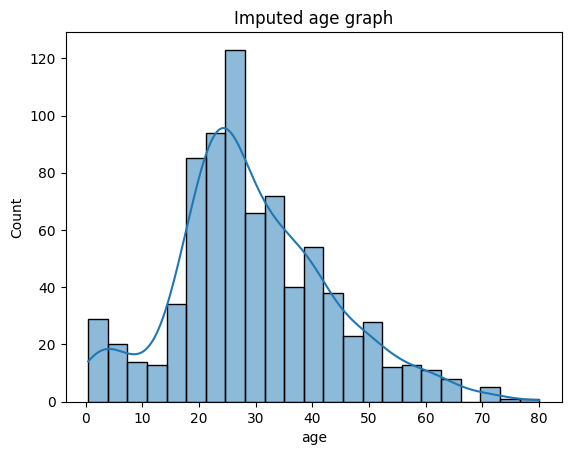

In [153]:
sns.histplot(df['age'], kde=True)
plt.title("Imputed age graph")
plt.show()

In [ ]:
# Finding rows with missing embarked

missing_embarked = df[df['embarked'].isna()]
print(f"Rows with missing embarked: {len(missing_embarked)}")
print("\nMissing embarked rows:")
print(missing_embarked[['fare', 'pclass', 'embarked']])

Rows with missing embarked: 2

Missing embarked rows:
     fare  pclass embarked
61   80.0       1      NaN
829  80.0       1      NaN


In [155]:
# Fill missing embarked values with mode of same pclass
df['embarked'] = df.groupby('pclass')['embarked'].transform(lambda x: x.fillna(x.mode()[0] if len(x.mode()) > 0 else 'S'))

print(df['embarked'])

print(f"Missing values after fill: {df['embarked'].isna().sum()}")

0      S
1      C
2      S
3      S
4      S
      ..
885    Q
887    S
888    S
889    C
890    Q
Name: embarked, Length: 784, dtype: str
Missing values after fill: 0


In [170]:
#  Analyze deck column and decide whether to keep or drop

# Calculate percentage of missing values in deck
deck_mis = (df['deck'].isna().sum() / len(df)) * 100
print(f"Missing values in deck: {deck_mis:.1f}%")

# Create deck_known column
df['deck_known'] = df['deck'].notna()
print(f"\nDeck known: {df['deck_known'].sum()} passengers")
print(f"Deck unknown: {(~df['deck_known']).sum()} passengers")

# Calculate survival rate by deck_known
survival_by_deck = df.groupby('deck_known')['survived'].mean()
print("\nSurvival rate by deck_known:")
print(survival_by_deck.round(3))

Missing values in deck: 74.2%

Deck known: 202 passengers
Deck unknown: 582 passengers

Survival rate by deck_known:
deck_known
False    0.323
True     0.668
Name: survived, dtype: float64


## Part 3

family_size
1     446
2     154
3     101
4      28
5      13
6      22
7      12
8       6
11      2
Name: count, dtype: int64

Survival rate:
family_size
1     0.336323
2     0.551948
3     0.574257
4     0.714286
5     0.230769
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: survived, dtype: float64


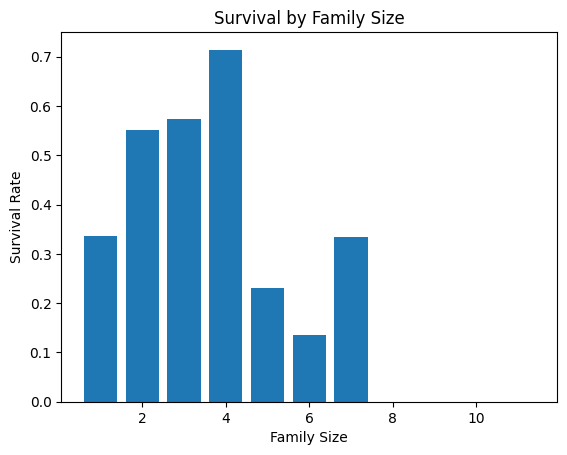


Highest: 4
Lowest: 8


In [176]:
# Create family size
df['family_size'] = df['sibsp'] + df['parch'] + 1

# Check distribution
print(df['family_size'].value_counts().sort_index())

# Check if passenger is alone
df['is_alone'] = df['family_size'] == 1

# Survival rate by family size
survival = df.groupby('family_size')['survived'].mean()

print("\nSurvival rate:")
print(survival)

# Plot
plt.bar(survival.index, survival.values)
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")
plt.title("Survival by Family Size")
plt.show()

# Highest & lowest
print("\nHighest:", survival.idxmax())
print("Lowest:", survival.idxmin())

In [177]:
# Analyze who column vs is_child

# Survival rate by 'who'
print(df.groupby('who')['survived'].mean())

# Create is_child column
df['is_child'] = df['age_imputed'] < 18

# Compare 'who' and is_child
print("\nComparison:")
print(pd.crosstab(df['who'] == 'child', df['is_child']))

# Find mismatches
mismatch = df[(df['who'] != 'child') & (df['is_child'])]

print("\nMismatch count:", len(mismatch))
print(mismatch[['age_imputed', 'who']].head())

who
child    0.585366
man      0.188470
woman    0.756972
Name: survived, dtype: float64

Comparison:
is_child  False  True 
who                   
False       674     28
True          0     82

Mismatch count: 28
     age_imputed    who
68          17.0  woman
71          16.0  woman
84          17.0  woman
86          16.0    man
114         17.0  woman


In [178]:
# Create fare_per_person and analyze fare brackets

# Create fare per person
df['fare_per_person'] = df['fare'] / df['family_size']

# Create brackets
df['fare_bracket'] = pd.cut(df['fare'], [0, 10, 25, 50, 100, 600])
df['fare_pp_bracket'] = pd.cut(df['fare_per_person'], [0, 10, 25, 50, 100, 600])

# Survival rates
print(df.groupby('fare_bracket')['survived'].mean())
print(df.groupby('fare_pp_bracket')['survived'].mean())

# Mismatch (high total fare but low per person)
mismatch = df[(df['fare'] > 100) & (df['fare_per_person'] < 10)]

print("\nMismatch count:", len(mismatch))
print(mismatch[['fare', 'family_size', 'fare_per_person']].head())

fare_bracket
(0, 10]       0.230159
(10, 25]      0.430000
(25, 50]      0.423529
(50, 100]     0.676768
(100, 600]    0.735849
Name: survived, dtype: float64
fare_pp_bracket
(0, 10]       0.301932
(10, 25]      0.442177
(25, 50]      0.580000
(50, 100]     0.658537
(100, 600]    0.818182
Name: survived, dtype: float64

Mismatch count: 0
Empty DataFrame
Columns: [fare, family_size, fare_per_person]
Index: []


## Part 4


sex     pclass
female  1         0.967742
        2         0.917808
        3         0.472441
male    1         0.371901
        2         0.184783
        3         0.158273
Name: survived, dtype: float64


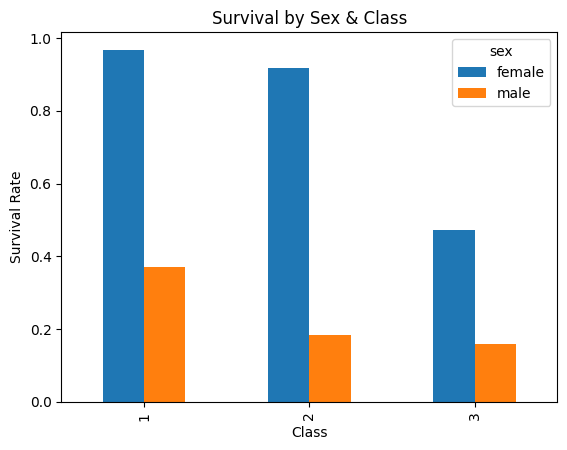


Highest male: 1
Lowest female: 3


In [179]:
#  Survival rate by sex and pclass

# Survival rate
print(df.groupby(['sex', 'pclass'])['survived'].mean())

# Plot
pivot = df.pivot_table(values='survived', index='pclass', columns='sex')
pivot.plot(kind='bar')

plt.xlabel("Class")
plt.ylabel("Survival Rate")
plt.title("Survival by Sex & Class")
plt.show()

# Highest / lowest
male = df[df['sex'] == 'male'].groupby('pclass')['survived'].mean()
female = df[df['sex'] == 'female'].groupby('pclass')['survived'].mean()

print("\nHighest male:", male.idxmax())
print("Lowest female:", female.idxmin())

In [180]:
# Survival rate by embark_town and pclass

# Survival by town
print(df.groupby('embark_town')['survived'].mean())

# Survival by town and class
print(df.groupby(['embark_town', 'pclass'])['survived'].mean())

# Class distribution
print(df.groupby('embark_town')['pclass'].value_counts(normalize=True).unstack())

print("\nConclusion: Difference is mainly due to passenger class.")

embark_town
Cherbourg      0.580645
Queenstown     0.338983
Southampton    0.371479
Name: survived, dtype: float64
embark_town  pclass
Cherbourg    1         0.698795
             2         0.529412
             3         0.418182
Queenstown   1         0.500000
             2         0.666667
             3         0.314815
Southampton  1         0.582677
             2         0.503448
             3         0.216216
Name: survived, dtype: float64
pclass              1         2         3
embark_town                              
Cherbourg    0.535484  0.109677  0.354839
Queenstown   0.033898  0.050847  0.915254
Southampton  0.223592  0.255282  0.521127

Conclusion: Difference is mainly due to passenger class.


alone
False    0.511834
True     0.336323
Name: survived, dtype: float64
family_size
1     0.336
2     0.552
3     0.574
4     0.714
5     0.231
6     0.136
7     0.333
8     0.000
11    0.000
Name: survived, dtype: float64


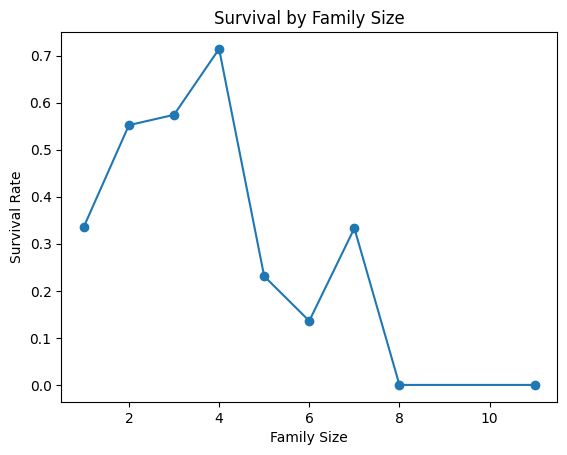


Best: 4
Worst: 8


In [181]:
# : Survival by alone and family_size


# Survival by alone
print(df.groupby('alone')['survived'].mean())

# Survival by family size
print(survival_by_family)

# Plot
plt.plot(survival_by_family.index, survival_by_family.values, marker='o')
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")
plt.title("Survival by Family Size")
plt.show()

# Best & worst
print("\nBest:", highest_family)
print("Worst:", lowest_family)

## Part 5

age_bin
(0, 10]     0.587302
(10, 20]    0.403670
(20, 30]    0.367491
(30, 40]    0.464088
(40, 50]    0.380952
(50, 60]    0.404762
(60, 70]    0.235294
(70, 80]    0.200000
Name: survived, dtype: float64


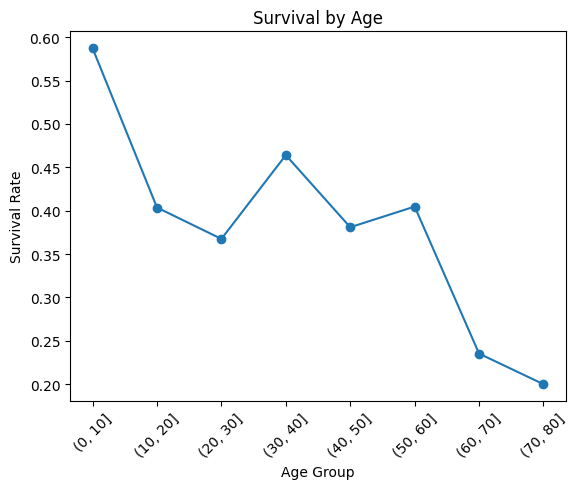


Best: (0, 10]
Worst: (70, 80]


In [182]:
#  Age bin analysis

# Create age bins
df['age_bin'] = pd.cut(df['age_imputed'], [0,10,20,30,40,50,60,70,80])

# Survival rate
survival_age = df.groupby('age_bin')['survived'].mean()
print(survival_age)

# Plot
plt.plot(survival_age.index.astype(str), survival_age.values, marker='o')
plt.xticks(rotation=45)
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")
plt.title("Survival by Age")
plt.show()

# Best & worst
print("\nBest:", survival_age.idxmax())
print("Worst:", survival_age.idxmin())

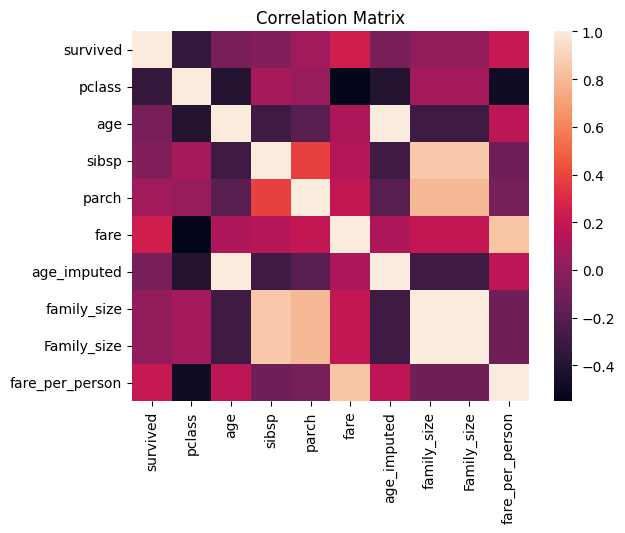


Top 3:
pclass             0.332658
fare               0.246769
fare_per_person    0.209104
Name: survived, dtype: float64

Highest pair:
pclass  pclass    1.0
dtype: float64


In [183]:
# : Correlation matrix

# Numeric columns
num = df.select_dtypes(include='number')

# Correlation
corr = num.corr()

# Heatmap
sns.heatmap(corr)
plt.title("Correlation Matrix")
plt.show()

# Top correlations with survived
top = corr['survived'].drop('survived').abs().sort_values(ascending=False)
print("\nTop 3:")
print(top.head(3))

# Highest correlation between features
corr2 = corr.drop('survived', axis=0).drop('survived', axis=1)
print("\nHighest pair:")
print(corr2.unstack().sort_values(ascending=False).drop_duplicates().head(1))

In [185]:
# : Top factors influencing survival

# Top 3 factors
top = df.head(3)
print("Top 3 factors:")
print(top)

# Create simple scores
df['sex_score'] = (df['sex'] == 'female').astype(int)
df['pclass_score'] = 4 - df['pclass']
df['fare_score'] = pd.qcut(df['fare'], 4, labels=False)

df['score'] = df['sex_score'] + df['pclass_score'] + df['fare_score']

# Survival by score
survival_score = df.groupby('score')['survived'].mean()
print("\nSurvival by score:")
print(survival_score)

# Best & worst
print("\nBest:", survival_score.idxmax())
print("Worst:", survival_score.idxmin())

# Pivot (sex vs class)
print("\nSex vs Class:")
print(df.pivot_table(values='survived', index='sex', columns='pclass'))

Top 3 factors:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   

     who  ...  deck_known family_size is_alone_calc is_alone  Family_size  \
0    man  ...       False           2         False    False            2   
1  woman  ...        True           2         False    False            2   
2  woman  ...       False           1          True     True            1   

   is_child  fare_per_person  fare_bracket  fare_pp_bracket   age_bin  
0     False          3.62500       (0, 10]          (0, 10]  (20, 30]  
1     False         35.64165     (50, 100]         (25, 50]  (30, 40]  
2     False          7.92500       (0, 10]          (0, 10]  (20, 30]  

[3 rows x 26 columns]

Survival by score:
score
1    0.145455
2    0.376238
3    0

In [186]:
print("\n" + "="*70)
print("✅ TITANIC DATA ANALYSIS COMPLETED")
print("="*70)
print(f"""
Key Accomplishments:
• Loaded and inspected dataset ({df.shape[0]} rows, {df.shape[1]} columns)
• Handled missing values in age, embarked, and deck
• Created engineered features: family_size, is_alone, fare_per_person
• Performed comprehensive EDA with visualizations
• Identified top survival factors: sex, class, fare
• Built survival score combining key factors
""")


✅ TITANIC DATA ANALYSIS COMPLETED

Key Accomplishments:
• Loaded and inspected dataset (784 rows, 30 columns)
• Handled missing values in age, embarked, and deck
• Created engineered features: family_size, is_alone, fare_per_person
• Performed comprehensive EDA with visualizations
• Identified top survival factors: sex, class, fare
• Built survival score combining key factors

